<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Semanal Nº0
#### Nombre y Apellido: Angel Vargas


# Introducción

En este trabajo se analizó la generación de señales senoidales y su representación en tiempo discreto, enfocándose en el proceso de muestreo.

La señal senoidal a usarse se puede expresarse como:

$$
x(t) = dc + v_{max} \sin(2\pi f t + \phi)
$$

Para poder trabajarla digitalmente, es necesario discretizar el tiempo, es decconvertir el tiempo continuo en instantes separados (muestras). Se observa la señal solo en ciertos puntos, no de forma continua.

$$
T_s = \frac{1}{f_s}
$$

$$
t[n] = nT_s
$$

Entonces, la señal discreta queda:

$$
x[n] = dc + v_{max} \sin(2\pi f n T_s + \phi)
$$

En este trabajo se utilizó:

- $f_s = 100 \, Hz$
- $N = 100$

por lo que la frecuencia de Nyquist es:

$$
f_N = \frac{f_s}{2} = 50 \, Hz
$$

Es la máxima frecuencia que se puede representar correctamente en una señal digital sin que aparezca aliasing, es decir que la señal muestreada no representa la frecuencia real, sino una frecuencia falsa (alias).

Si una señal tiene componentes con frecuencia mayor, se “pliegan” y se observan como frecuencias más bajas (aliasing).

# Análisis y desarrollo

Se generaron señales sinusoidales variando la frecuencia para observar su comportamiento frente al muestreo.



In [3]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):

    # Vector de tiempo
    tt = np.arange(0, nn) / fs
    velang=2 * np.pi * ff
    # Señal senoidal
    xx = dc + vmax * np.sin(velang * tt + ph)

    return tt, xx



### Caso 1: $f = 2 \, Hz$

Se cumple ampliamente el teorema de muestreo:

$$
f \ll f_N
$$

La señal queda bien representada, con muchas muestras por período.

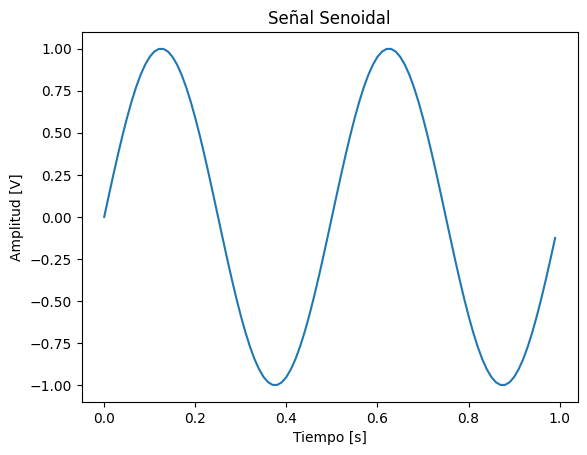

In [4]:
    N = 100     
    fs = 100 
    ffs= 2
    vmaxs= 1
    dcs= 0
    fas=0
    # Llamar a la función
    tt, xx = mi_funcion_sen(vmax=vmaxs, dc=dcs, ff=ffs, ph=fas, nn=N, fs=fs)
    # Graficar
    plt.figure()
    plt.plot(tt, xx)
    plt.title("Señal Senoidal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.show()




### Caso 2: $f = 50 \, Hz$

Se trabaja en el límite de Nyquist:

$$
f = f_N
$$

Solo hay 2 muestras por período. Como la fase es cero:

$$
x[n] = \sin(\pi n) = 0
$$

La señal queda reducida a valores nulos. Es un caso de muestreo crítico.


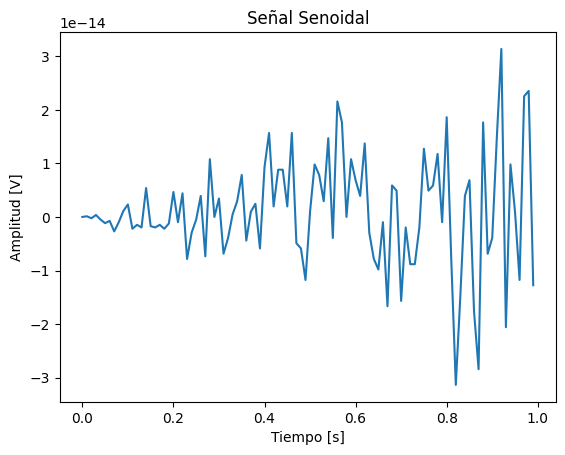

In [5]:

    tt1, xx1 = mi_funcion_sen(vmax=vmaxs, dc=dcs, ff=50, ph=fas, nn=N, fs=fs)
    plt.figure()
    plt.plot(tt1, xx1)
    plt.title("Señal Senoidal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.show()



### Caso 3: $f = 99 \, Hz$

No se cumple el teorema:

$$
f > f_N
$$

Aparece aliasing:

$$
f_{alias} = |f - f_s| = |99 - 100| = 1 \, Hz
$$

La señal se observa como una de baja frecuencia.


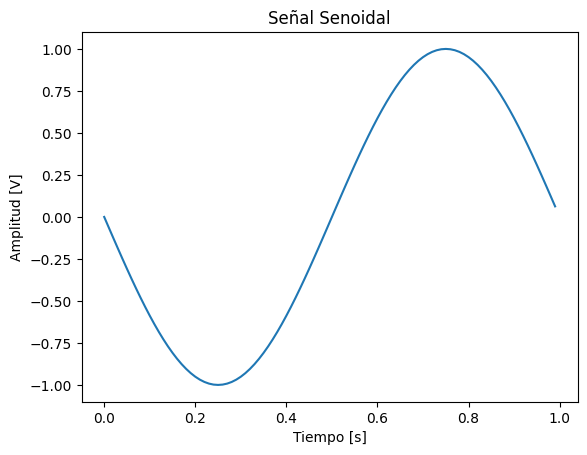

In [6]:
    tt2,xx2 = mi_funcion_sen(vmax=vmaxs, dc=dcs, ff=99, ph=fas, nn=N, fs=fs)
    plt.figure()
    plt.plot(tt2, xx2)
    plt.title("Señal Senoidal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.show()


### Caso 4: $f = 101 \, Hz$

$$
f_{alias} = |101 - 100| = 1 \, Hz
$$

También se observa una señal de 1 Hz.


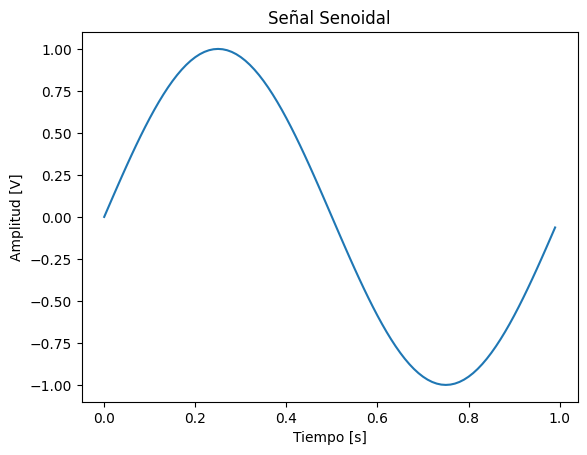

In [7]:

    tt3,xx3 = mi_funcion_sen(vmax=vmaxs, dc=dcs, ff=101, ph=fas, nn=N, fs=fs)
    plt.figure()
    plt.plot(tt3, xx3)
    plt.title("Señal Senoidal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.show()  



### Caso 5: $f = 201 \, Hz$

$$
f_{alias} = |201 - 2 \cdot 100| = 1 \, Hz
$$

La señal vuelve a plegarse dentro de la banda de Nyquist.

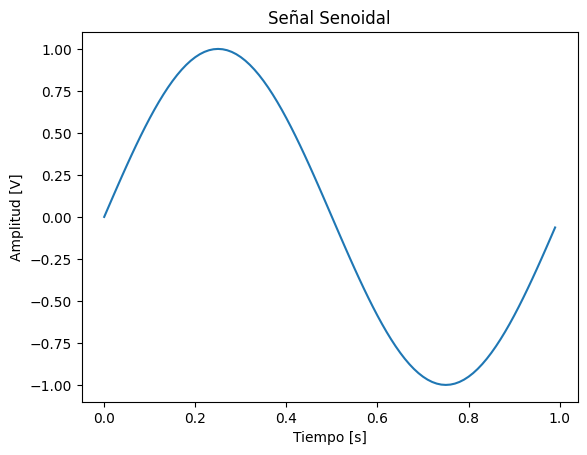

In [8]:

    tt4,xx4 = mi_funcion_sen(vmax=vmaxs, dc=dcs, ff=201, ph=fas, nn=N, fs=fs)
    plt.figure()
    plt.plot(tt4, xx4)
    plt.title("Señal Senoidal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.show()

# Conclusión

Se observo que solo las señales con frecuencia menor a $f_s/2$ se representan correctamente.En el límite de Nyquist, la representación es crítica y depende de la fase. Para frecuencias mayores, como 99 Hz, 101 Hz y 201 Hz, aparece aliasing, donde la señal muestreada muestra una frecuencia distinta a la original, lo que implica pérdida de información.
En conclusión, la elección de la frecuencia de muestreo es fundamental para evitar distorsiones en la señal digital.